#💡 The Data Scientist's Roadmap: Working Backwards from the Goal

As data scientists, our first step is not to query the database, but to define the required input format for our final model. This "Goal-Oriented" approach is essential for building efficient and accurate data pipelines.

In this project, our goal is to create a Machine Learning feature set that adheres strictly to the clinical standard of the APACHE III variables.

Moreover, we may use APACHE III score, so I create it as well.

# The Critical First Step: Defining the Final Data Goal (PI Consultation)
Before writing a single line of SQL or Python code, a data scientist must clearly define the exact structure of the final feature set. Your image serves as this definition, or the "target schema."

**Why Consultation with the PI (Principal Investigator) is Essential**

In a clinical research or AI development setting, the PI—who possesses the clinical expertise—must validate this schema. This consultation confirms that the planned data is:

1. Clinically Valid: Does the final structure accurately reflect the necessary clinical criteria (e.g., using 24-hour worst values, including the correct comorbidities)?

2. Statistically Adequate: Does the data contain all the necessary features and target variables (like apache3_score and hospital_expire_flag) needed to run the planned analyses (e.g., mortality prediction, bias analysis)?

**Your image is the blueprint for the entire project**. By presenting this to the PI, you establish a shared understanding of the deliverables, preventing wasted effort on collecting the wrong data or calculating scores incorrectly.

Below is my image data at first


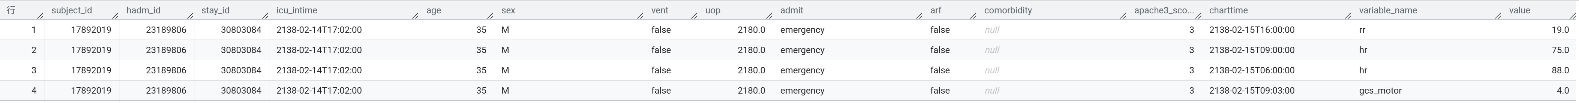

# APACHE III Variables Dataset Creation

## Objective:
- Create a dataset for
  - including APACHE III variables and
  - for calculating APACHE III scores
    - Extract worst values within 24 hours of ICU admission
- Build a complete dataset for AI vulnerability analysis

## Required Variables:

Continuous Variables (need both max and min values):
- Vital Signs: hr (heart rate), map (mean arterial pressure), temp (temperature), rr (respiratory rate)
- GCS: eye (eye opening), motor (motor response), verbal (verbal response)

- Blood Gas: pao2 (arterial O2), pco2 (arterial CO2), ph, aa_grad (A-a gradient), fio2 (fraction inspired O2)
- Hematology: hct (hematocrit), wbc (white blood cell count)
- Renal: scr (serum creatinine), bun (blood urea nitrogen), uop (urine output)
- Electrolytes/Metabolism: sodium, glucose
- Liver: bili (bilirubin), albumin
- Other: age

Binary/Categorical Variables to calcurate APACHE III "**score**":
- vent: mechanical ventilation (TRUE/FALSE)
- arf: acute renal failure (TRUE/FALSE)
- admit: admission type (elective/emergency)
- comorbidity: comorbid conditions  
*These variables will not be include your model.Only use APACHE III score calculation.



# Step 1: Setup

We import Pandas for efficient manipulation of structured data (DataFrames), NumPy for numerical operations, and datetime for handling time-related calculations, which are essential for defining the 24-hour observation window.

In [1]:
# =============================================================================
# Step 1: Setup
# Import necessary libraries for data manipulation and BigQuery operations
# =============================================================================

# %%
import pandas as pd
import numpy as np
from datetime import datetime

print("✓ Setup complete")

✓ Setup complete


# Step 2: Explore sepsis3_cohort Table Structure

This initial table (sepsis3_cohort) is the base for all subsequent data joins and filtering. We must confirm:

- Data Types: Ensure that key columns like stay_id (join key) and icu_intime (time anchor) have the correct data types (INT64, DATETIME) to prevent errors during the data extraction process.

- Availability: Confirm the existence of required columns like subject_id, hadm_id, and icu_intime.


In [2]:


# Step 2-1: Check Table Structure
# Query the INFORMATION_SCHEMA to see all columns, their data types, and whether they allow NULL values

# %%
%%bigquery
SELECT
  column_name,
  data_type,
  is_nullable
FROM `my-new-project-473015.my_mimiciv_derived.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'sepsis3_cohort'
ORDER BY ordinal_position

Query is running:   0%|          |

Downloading:   0%|          |

,column_name,data_type,is_nullable
0,subject_id,INT64,YES
1,stay_id,INT64,YES
2,hadm_id,INT64,YES
3,anchor_age,INT64,YES
4,gender,STRING,YES
5,icu_intime,DATETIME,YES
6,icu_outtime,DATETIME,YES
7,los_days,FLOAT64,YES
8,los_hours,FLOAT64,YES
9,suspected_infection_time,DATETIME,YES


# Step 3: Adding ventilation data  

Why is ventilation data needed?
Mechanical ventilation status is critical for the APACHE III Pulmonary Score.  

- Scoring Logic: If a patient is on an Invasive Ventilator (Vent = TRUE), the score is calculated using the Alveolar-arterial (A-a) Gradient instead of the $\text{PaO}_2$ (partial pressure of oxygen in arterial blood). This adjustment accounts for the altered respiratory mechanics in ventilated patients.  
- 24-Hour Rule: Consistent with APACHE III rules, we only flag ventilation use if it started within the first 24 hours of ICU admission.

Goal: Add ventilation data to sepsis3_cohort
- Determine if invasive ventilation was used within 24 hours of ICU admission
- Extract ventilation start and end times
- vent definition: InvasiveVent ONLY (excludes Tracheostomy, NonInvasiveVent, HFNC)

This script creates a new table with ventilation information added to the sepsis3_cohort

In [3]:
# =============================================================================
# Step 1: Create sepsis3_cohort with ventilation data
# This query will:
# - Join sepsis3_cohort with ventilation data
# - Filter for InvasiveVent only
# - Check if ventilation occurred within 24 hours of ICU admission
# - Add vent flag, vent_starttime, and vent_endtime columns
# =============================================================================
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent` AS
WITH vent_24h AS (
  SELECT
    s.stay_id,
    -- Check if any InvasiveVent occurred within 24 hours
    CASE
      WHEN COUNT(v.stay_id) > 0 THEN TRUE
      ELSE FALSE
    END AS vent,
    -- Get earliest ventilation start time within 24h window
    MIN(v.starttime) AS vent_starttime,
    -- Get latest ventilation end time within 24h window
    MAX(v.endtime) AS vent_endtime
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort` s
  LEFT JOIN `my-new-project-473015.my_mimiciv_derived.ventilation` v
    ON s.stay_id = v.stay_id
    AND v.ventilation_status = 'InvasiveVent'
    -- Ventilation must start within 24 hours of ICU admission
    AND v.starttime >= s.icu_intime
    AND v.starttime < DATETIME_ADD(s.icu_intime, INTERVAL 24 HOUR)
  GROUP BY s.stay_id
)
SELECT
  s.*,
  v.vent,
  v.vent_starttime,
  v.vent_endtime
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort` s
LEFT JOIN vent_24h v
  ON s.stay_id = v.stay_id;

SELECT 'Table created successfully!' AS status;

Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 4: Adding Urine Output Data

Goal: Add urine output data to sepsis3_cohort_with_vent
- Calculate total urine output within 24 hours of ICU admission
- Variable name: uop (urine output in mL)

This script creates a new table with urine output information added.

In [4]:
# =============================================================================
# Step 1: Create table with urine output data
# This query will:
# - Join with urine_output table
# - Sum all urine output values within 24 hours of ICU admission
# - Add uop column (total urine output in mL for 24 hours)
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop` AS
WITH uop_24h AS (
  SELECT
    s.stay_id,
    -- Sum all urine output within 24 hours of ICU admission
    SUM(u.urineoutput) AS uop
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent` s
  LEFT JOIN `my-new-project-473015.my_mimiciv_derived.urine_output` u
    ON s.stay_id = u.stay_id
    -- Urine output must be within 24 hours of ICU admission
    AND u.charttime >= s.icu_intime
    AND u.charttime < DATETIME_ADD(s.icu_intime, INTERVAL 24 HOUR)
  GROUP BY s.stay_id
)
SELECT
  s.*,
  COALESCE(u.uop, 0) AS uop
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent` s
LEFT JOIN uop_24h u
  ON s.stay_id = u.stay_id;

SELECT 'Table created successfully!' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 5: Add Admission Type

Admission type determines how the Comorbidity Score is applied.

- Elective vs. Emergency: APACHE III severity points for pre-existing conditions (comorbidities) are only added to the score for patients with emergency (non-elective) admissions.

- Patients admitted electively are generally assumed to be in a more stable, controlled state, so their underlying chronic diseases do not contribute to the acute severity score. This classification is vital for accurate scoring.
    

Goal: Add admission type to the cohort
- Extract admission type from admissions table
- Classify as 'elective' or 'emergency' for APACHE III scoring
- Variable name: admit

For APACHE III:
- elective: scheduled/planned admissions (no comorbidity points added)
- emergency: urgent/emergency admissions (comorbidity points are added)

In [5]:
# =============================================================================
# Step 1: Create table with admission type
# This query will:
# - Join with admissions table to get admission_type
# - Classify admission as elective or emergency
# - Add admit column
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit` AS
WITH admit_type AS (
  SELECT
    s.stay_id,
    s.hadm_id,
    -- Classify admission type for APACHE III
    -- ELECTIVE, EU OBSERVATION, EW EMER., AMBULATORY OBSERVATION, OBSERVATION ADMIT, SURGICAL SAME DAY ADMISSION
    -- vs URGENT, EMERGENCY
    CASE
      WHEN a.admission_type IN ('ELECTIVE', 'SURGICAL SAME DAY ADMISSION') THEN 'elective'
      ELSE 'emergency'
    END AS admit
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop` s
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
    ON s.hadm_id = a.hadm_id
)
SELECT
  s.*,
  a.admit
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop` s
LEFT JOIN admit_type a
  ON s.stay_id = a.stay_id;

SELECT 'Table created successfully!' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 6: Adding Acute Renal Failure (ARF)

Goal: Add acute renal failure (ARF) flag to the cohort
- Extract serum creatinine from lab events within 24 hours
- Calculate ARF based on APACHE III criteria
- Variable name: arf

ARF Definition for APACHE III:
- Serum Creatinine (SCr) >= 1.5 mg/dL
- AND Urine Output < 410 mL (24 hours)
- AND No chronic dialysis

For now, we will identify ARF based on SCr and UOP.
Chronic dialysis exclusion can be added later if needed.

In [6]:
# =============================================================================
# Step 1: Create table with ARF flag
# This query will:
# - Extract maximum serum creatinine within 24 hours of ICU admission
# - Calculate ARF based on SCr >= 1.5 AND uop < 410
# - Add scr (serum creatinine) and arf columns
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf` AS
WITH scr_24h AS (
  SELECT
    s.stay_id,
    -- Get maximum serum creatinine within 24 hours
    MAX(le.valuenum) AS scr_max
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit` s
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.labevents` le
    ON s.subject_id = le.subject_id
    AND s.hadm_id = le.hadm_id
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.d_labitems` d
    ON le.itemid = d.itemid
  WHERE
    -- Filter for creatinine lab tests
    LOWER(d.label) LIKE '%creatinine%'
    AND LOWER(d.label) NOT LIKE '%clear%'  -- exclude creatinine clearance
    AND LOWER(d.fluid) = 'blood'
    -- Within 24 hours of ICU admission
    AND le.charttime >= s.icu_intime
    AND le.charttime < DATETIME_ADD(s.icu_intime, INTERVAL 24 HOUR)
    -- Valid values only
    AND le.valuenum IS NOT NULL
    AND le.valuenum > 0
    AND le.valuenum < 20  -- exclude extreme outliers
  GROUP BY s.stay_id
),
arf_calculation AS (
  SELECT
    s.stay_id,
    scr.scr_max,
    -- ARF = TRUE if SCr >= 1.5 AND UOP < 410
    CASE
      WHEN scr.scr_max >= 1.5 AND s.uop < 410 THEN TRUE
      ELSE FALSE
    END AS arf
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit` s
  LEFT JOIN scr_24h scr
    ON s.stay_id = scr.stay_id
)
SELECT
  s.*,
  a.scr_max,
  a.arf
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit` s
LEFT JOIN arf_calculation a
  ON s.stay_id = a.stay_id;

SELECT 'Table created successfully!' AS status;

Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Explanation of next steps

## Why extract in Long Format?

To find the worst value (MAX/MIN) for each patient within the 24-hour window, we must first gather all individual measurements.

- Standardization: The "long format" (columns: stay_id, charttime, variable_name, value) standardizes data from various sources (labs, vitals, ABGs, GCS) into a single, unified structure.

- Aggregation Preparation: This structure is ideal for the next step, where we use the GROUP BY stay_id clause with aggregate functions (MAX, MIN) to efficiently calculate the single worst value for each variable and each patient.

This step extracts lab values, vital signs, and GCS components. GCS components (Eye, Motor, Verbal) are extracted separately because the APACHE III score is based on the worst score of each component, not the GCS total sum.

# Step 7: Extract Vital Signs (Long Format)

Goal: Extract all vital sign measurements within 24 hours of ICU admission
- Create long-format table with all measurements over time
- Variables: hr, map, temp, rr
- Data source: my_mimiciv_derived.vitalsign

Note: FiO2 will be extracted separately in Step 7 from charttime and derived.bg

Table structure:  
stay_id | charttime | variable_name | value

In [7]:

# =============================================================================
# Step 1: Create vital signs table in long format
# This query will:
# - Extract all vital sign measurements within 24 hours of ICU admission
# - Store in long format (one row per measurement)
# - Include: hr, map, temp, rr
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_vitals_24h_raw` AS
WITH cohort AS (
  SELECT
    stay_id,
    icu_intime,
    DATETIME_ADD(icu_intime, INTERVAL 24 HOUR) AS icu_24h
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf`
)
-- Heart Rate
SELECT
  c.stay_id,
  v.charttime,
  'hr' AS variable_name,
  v.heart_rate AS value
FROM cohort c
INNER JOIN `my-new-project-473015.my_mimiciv_derived.vitalsign` v
  ON c.stay_id = v.stay_id
  AND v.charttime >= c.icu_intime
  AND v.charttime < c.icu_24h
WHERE v.heart_rate IS NOT NULL
  AND v.heart_rate > 0
  AND v.heart_rate <= 300  -- Exclude extreme outliers

UNION ALL

-- Mean Arterial Pressure
SELECT
  c.stay_id,
  v.charttime,
  'map' AS variable_name,
  v.mbp AS value
FROM cohort c
INNER JOIN `my-new-project-473015.my_mimiciv_derived.vitalsign` v
  ON c.stay_id = v.stay_id
  AND v.charttime >= c.icu_intime
  AND v.charttime < c.icu_24h
WHERE v.mbp IS NOT NULL
  AND v.mbp > 0
  AND v.mbp <= 250  -- Exclude extreme outliers

UNION ALL

-- Temperature (Celsius)
SELECT
  c.stay_id,
  v.charttime,
  'temp' AS variable_name,
  v.temperature AS value
FROM cohort c
INNER JOIN `my-new-project-473015.my_mimiciv_derived.vitalsign` v
  ON c.stay_id = v.stay_id
  AND v.charttime >= c.icu_intime
  AND v.charttime < c.icu_24h
WHERE v.temperature IS NOT NULL
  AND v.temperature > 25
  AND v.temperature < 45  -- Exclude extreme outliers (Celsius range)

UNION ALL

-- Respiratory Rate
SELECT
  c.stay_id,
  v.charttime,
  'rr' AS variable_name,
  v.resp_rate AS value
FROM cohort c
INNER JOIN `my-new-project-473015.my_mimiciv_derived.vitalsign` v
  ON c.stay_id = v.stay_id
  AND v.charttime >= c.icu_intime
  AND v.charttime < c.icu_24h
WHERE v.resp_rate IS NOT NULL
  AND v.resp_rate > 0
  AND v.resp_rate <= 70  -- Exclude extreme outliers

ORDER BY stay_id, charttime, variable_name;

SELECT 'Table created successfully!' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 8: Extract FiO2 (Long Format)


Goal: Extract all FiO2 measurements within 24 hours of ICU admission
- Create long-format table with all measurements over time
- Variable: fio2 (fraction of inspired oxygen, as percentage 0-100)
- Data sources:
  1. physionet-data.mimiciv_3_1_derived.bg (blood gas measurements)
  2. physionet-data.mimiciv_3_1_icu.chartevents (ventilator settings)

Reference: https://github.com/MIT-LCP/mimic-code/blob/main/mimic-iv/concepts/measurement/bg.sql

Table structure:  
stay_id | charttime | variable_name | source | value

In [8]:

# =============================================================================
# Step 1: Create FiO2 table in long format
# This query will:
# - Extract all FiO2 measurements within 24 hours of ICU admission from TWO sources:
#   1. Blood gas table (bg) - less frequent but accurate
#   2. Chartevents - more frequent ventilator settings
# - Store in long format (one row per measurement)
# - Add 'source' column to track data origin
# - Normalize FiO2 to percentage (0-100)
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_fio2_24h_raw` AS
WITH cohort AS (
  SELECT
    stay_id,
    subject_id,
    hadm_id,
    icu_intime,
    DATETIME_ADD(icu_intime, INTERVAL 24 HOUR) AS icu_24h
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf`
)
-- Extract FiO2 from blood gas table
SELECT
  c.stay_id,
  bg.charttime,
  'fio2' AS variable_name,
  'bg' AS source,
  -- FiO2 is stored as percentage in bg table (typically 21-100)
  -- Some values might be stored as fraction (0-1), normalize to percentage
  CASE
    WHEN bg.fio2 <= 1 THEN bg.fio2 * 100  -- Convert fraction to percentage
    WHEN bg.fio2 > 1 AND bg.fio2 <= 100 THEN bg.fio2  -- Already percentage
    ELSE NULL
  END AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
  ON c.subject_id = bg.subject_id
  AND c.hadm_id = bg.hadm_id
  AND bg.charttime >= c.icu_intime
  AND bg.charttime < c.icu_24h
WHERE bg.fio2 IS NOT NULL
  AND bg.fio2 > 0
  AND ((bg.fio2 <= 1) OR (bg.fio2 >= 21 AND bg.fio2 <= 100))  -- Valid ranges

UNION ALL

-- Extract FiO2 from chartevents
SELECT
  c.stay_id,
  ce.charttime,
  'fio2' AS variable_name,
  'chartevents' AS source,
  -- Normalize FiO2 to percentage (0-100)
  CASE
    WHEN ce.valuenum <= 1 THEN ce.valuenum * 100  -- Convert fraction to percentage
    WHEN ce.valuenum > 1 AND ce.valuenum <= 100 THEN ce.valuenum  -- Already percentage
    ELSE NULL
  END AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
  ON c.stay_id = ce.stay_id
  AND ce.charttime >= c.icu_intime
  AND ce.charttime < c.icu_24h
INNER JOIN `physionet-data.mimiciv_3_1_icu.d_items` d
  ON ce.itemid = d.itemid
WHERE d.itemid = 223835  -- FiO2 (Inspired O2 Fraction) only; 220277 = SpO2 removed
  AND ce.valuenum IS NOT NULL
  AND ce.valuenum > 0
  AND ((ce.valuenum <= 1) OR (ce.valuenum >= 21 AND ce.valuenum <= 100))

ORDER BY stay_id, charttime;

SELECT 'Table created successfully!' AS status;




Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 9: Extract Lab Values (Long Format)


Goal: Extract all lab value measurements within 24 hours of ICU admission
- Create long-format table with all measurements over time
- Variables: sodium, bun, hct, wbc, albumin, bili, glucose, scr
- Data sources:
  1. physionet-data.mimiciv_3_1_derived.enzyme (bilirubin)
  2. physionet-data.mimiciv_3_1_derived.chemistry (bun, sodium, glucose, creatinine, albumin)
  3. physionet-data.mimiciv_3_1_derived.complete_blood_count (wbc, hematocrit)

Table structure:  
stay_id | charttime | variable_name | value

In [9]:
# =============================================================================
# Step 1: Create lab values table in long format
# This query will:
# - Extract all lab measurements within 24 hours of ICU admission from THREE sources
# - Store in long format (one row per measurement)
# - Include: sodium, bun, hct, wbc, albumin, bili, glucose, scr
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_labs_24h_raw` AS
WITH cohort AS (
  SELECT
    stay_id,
    subject_id,
    hadm_id,
    icu_intime,
    DATETIME_SUB(icu_intime, INTERVAL 24 HOUR) AS icu_minus_24h,  -- NEW: 24h before ICU
    DATETIME_ADD(icu_intime, INTERVAL 24 HOUR) AS icu_plus_24h
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf`
)
-- Extract from enzyme table: Total Bilirubin
SELECT
  c.stay_id,
  e.charttime,
  'bili' AS variable_name,
  e.bilirubin_total AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.enzyme` e
  ON c.subject_id = e.subject_id
  AND c.hadm_id = e.hadm_id
  AND e.charttime >= c.icu_minus_24h   -- CHANGED
  AND e.charttime < c.icu_plus_24h
WHERE e.bilirubin_total IS NOT NULL
  AND e.bilirubin_total >= 0
  AND e.bilirubin_total <= 50

UNION ALL

-- Extract from chemistry table: BUN
SELECT
  c.stay_id,
  ch.charttime,
  'bun' AS variable_name,
  ch.bun AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.chemistry` ch
  ON c.subject_id = ch.subject_id
  AND c.hadm_id = ch.hadm_id
  AND ch.charttime >= c.icu_minus_24h   -- CHANGED
  AND ch.charttime < c.icu_plus_24h
WHERE ch.bun IS NOT NULL
  AND ch.bun >= 0
  AND ch.bun <= 300

UNION ALL

-- Extract from chemistry table: Sodium
SELECT
  c.stay_id,
  ch.charttime,
  'sodium' AS variable_name,
  ch.sodium AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.chemistry` ch
  ON c.subject_id = ch.subject_id
  AND c.hadm_id = ch.hadm_id
  AND ch.charttime >= c.icu_minus_24h   -- CHANGED
  AND ch.charttime < c.icu_plus_24h
WHERE ch.sodium IS NOT NULL
  AND ch.sodium >= 100
  AND ch.sodium <= 200

UNION ALL

-- Extract from chemistry table: Glucose
SELECT
  c.stay_id,
  ch.charttime,
  'glucose' AS variable_name,
  ch.glucose AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.chemistry` ch
  ON c.subject_id = ch.subject_id
  AND c.hadm_id = ch.hadm_id
  AND ch.charttime >= c.icu_minus_24h   -- CHANGED
  AND ch.charttime < c.icu_plus_24h
WHERE ch.glucose IS NOT NULL
  AND ch.glucose >= 0
  AND ch.glucose <= 1000

UNION ALL

-- Extract from chemistry table: Creatinine
SELECT
  c.stay_id,
  ch.charttime,
  'scr' AS variable_name,
  ch.creatinine AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.chemistry` ch
  ON c.subject_id = ch.subject_id
  AND c.hadm_id = ch.hadm_id
  AND ch.charttime >= c.icu_minus_24h   -- CHANGED
  AND ch.charttime < c.icu_plus_24h
WHERE ch.creatinine IS NOT NULL
  AND ch.creatinine >= 0
  AND ch.creatinine <= 30

UNION ALL

-- Extract from chemistry table: Albumin
SELECT
  c.stay_id,
  ch.charttime,
  'albumin' AS variable_name,
  ch.albumin AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.chemistry` ch
  ON c.subject_id = ch.subject_id
  AND c.hadm_id = ch.hadm_id
  AND ch.charttime >= c.icu_minus_24h   -- CHANGED
  AND ch.charttime < c.icu_plus_24h
WHERE ch.albumin IS NOT NULL
  AND ch.albumin >= 0
  AND ch.albumin <= 10

UNION ALL

-- Extract from complete_blood_count table: WBC
SELECT
  c.stay_id,
  cbc.charttime,
  'wbc' AS variable_name,
  cbc.wbc AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.complete_blood_count` cbc
  ON c.subject_id = cbc.subject_id
  AND c.hadm_id = cbc.hadm_id
  AND cbc.charttime >= c.icu_minus_24h   -- CHANGED
  AND cbc.charttime < c.icu_plus_24h
WHERE cbc.wbc IS NOT NULL
  AND cbc.wbc >= 0
  AND cbc.wbc <= 500

UNION ALL

-- Extract from complete_blood_count table: Hematocrit
SELECT
  c.stay_id,
  cbc.charttime,
  'hct' AS variable_name,
  cbc.hematocrit AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.complete_blood_count` cbc
  ON c.subject_id = cbc.subject_id
  AND c.hadm_id = cbc.hadm_id
  AND cbc.charttime >= c.icu_minus_24h   -- CHANGED
  AND cbc.charttime < c.icu_plus_24h
WHERE cbc.hematocrit IS NOT NULL
  AND cbc.hematocrit >= 10
  AND cbc.hematocrit <= 75

ORDER BY stay_id, charttime, variable_name;

SELECT 'Labs table created successfully (time window: -24h to +24h)' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Labs table created successfully (time window: ...


# Step 10: Extract Blood Gas Values (Long Format)

Goal: Extract all blood gas measurements within 24 hours of ICU admission
- Create long-format table with all measurements over time
- Variables: ph, pao2, pco2, aa_grad
- Data source: physionet-data.mimiciv_3_1_derived.bg

Note: Focus on arterial blood gas values for accuracy

Table structure:  
stay_id | charttime | variable_name | value


In [10]:

# =============================================================================
# Step 1: Create blood gas values table in long format
# This query will:
# - Extract all blood gas measurements within 24 hours of ICU admission
# - Store in long format (one row per measurement)
# - Include: ph, pao2, pco2, aa_grad
# - Prioritize arterial specimens
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_bloodgas_24h_raw` AS
WITH cohort AS (
  SELECT
    stay_id,
    subject_id,
    hadm_id,
    icu_intime,
    DATETIME_SUB(icu_intime, INTERVAL 24 HOUR) AS icu_minus_24h,  -- NEW: 24h before ICU
    DATETIME_ADD(icu_intime, INTERVAL 24 HOUR) AS icu_plus_24h
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf`
)
-- Extract pH
SELECT
  c.stay_id,
  bg.charttime,
  'ph' AS variable_name,
  bg.ph AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
  ON c.subject_id = bg.subject_id
  AND c.hadm_id = bg.hadm_id
  AND bg.charttime >= c.icu_minus_24h   -- CHANGED
  AND bg.charttime < c.icu_plus_24h
WHERE bg.ph IS NOT NULL
  AND bg.ph >= 6.5
  AND bg.ph <= 8.0

UNION ALL

-- Extract PaO2 (arterial oxygen)
SELECT
  c.stay_id,
  bg.charttime,
  'pao2' AS variable_name,
  bg.po2 AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
  ON c.subject_id = bg.subject_id
  AND c.hadm_id = bg.hadm_id
  AND bg.charttime >= c.icu_minus_24h   -- CHANGED
  AND bg.charttime < c.icu_plus_24h
WHERE bg.po2 IS NOT NULL
  AND bg.po2 > 0
  AND bg.po2 <= 700

UNION ALL

-- Extract PCO2 (arterial CO2)
SELECT
  c.stay_id,
  bg.charttime,
  'pco2' AS variable_name,
  bg.pco2 AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
  ON c.subject_id = bg.subject_id
  AND c.hadm_id = bg.hadm_id
  AND bg.charttime >= c.icu_minus_24h   -- CHANGED
  AND bg.charttime < c.icu_plus_24h
WHERE bg.pco2 IS NOT NULL
  AND bg.pco2 > 0
  AND bg.pco2 <= 200

UNION ALL

-- Extract A-a gradient (calculated)
SELECT
  c.stay_id,
  bg.charttime,
  'aa_grad' AS variable_name,
  bg.aado2_calc AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
  ON c.subject_id = bg.subject_id
  AND c.hadm_id = bg.hadm_id
  AND bg.charttime >= c.icu_minus_24h   -- CHANGED
  AND bg.charttime < c.icu_plus_24h
WHERE bg.aado2_calc IS NOT NULL
  AND bg.aado2_calc >= 0
  AND bg.aado2_calc <= 700

ORDER BY stay_id, charttime, variable_name;

SELECT 'Blood gas table created successfully (time window: -24h to +24h)' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Blood gas table created successfully (time win...


# Step 11: Extract GCS Components (Long Format)

Goal: Extract all GCS measurements within 24 hours of ICU admission
- Create long-format table with all measurements over time
- Variables: gcs_eyes, gcs_motor, gcs_verbal
- Data source: physionet-data.mimiciv_3_1_derived.gcs

GCS Components:
- Eye opening response: 1-4 (1=none, 4=spontaneous)
- Motor response: 1-6 (1=none, 6=obeys commands)
- Verbal response: 1-5 (1=none, 5=oriented)

Table structure:  
stay_id | charttime | variable_name | value


In [11]:

# =============================================================================
# Step 1: Create GCS components table in long format
# This query will:
# - Extract all GCS measurements within 24 hours of ICU admission
# - Store in long format (one row per measurement per component)
# - Include: gcs_eye, gcs_motor, gcs_verbal
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_gcs_24h_raw` AS
WITH cohort AS (
  SELECT
    stay_id,
    subject_id,
    hadm_id,
    icu_intime,
    DATETIME_ADD(icu_intime, INTERVAL 24 HOUR) AS icu_24h
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf`
)
-- Extract GCS Eye
SELECT
  c.stay_id,
  g.charttime,
  'gcs_eye' AS variable_name,
  CAST(g.gcs_eyes AS FLOAT64) AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.gcs` g
  ON c.stay_id = g.stay_id
  AND g.charttime >= c.icu_intime
  AND g.charttime < c.icu_24h
WHERE g.gcs_eyes IS NOT NULL
  AND g.gcs_eyes >= 1
  AND g.gcs_eyes <= 4

UNION ALL

-- Extract GCS Motor
SELECT
  c.stay_id,
  g.charttime,
  'gcs_motor' AS variable_name,
  CAST(g.gcs_motor AS FLOAT64) AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.gcs` g
  ON c.stay_id = g.stay_id
  AND g.charttime >= c.icu_intime
  AND g.charttime < c.icu_24h
WHERE g.gcs_motor IS NOT NULL
  AND g.gcs_motor >= 1
  AND g.gcs_motor <= 6

UNION ALL

-- Extract GCS Verbal
SELECT
  c.stay_id,
  g.charttime,
  'gcs_verbal' AS variable_name,
  CAST(g.gcs_verbal AS FLOAT64) AS value
FROM cohort c
INNER JOIN `physionet-data.mimiciv_3_1_derived.gcs` g
  ON c.stay_id = g.stay_id
  AND g.charttime >= c.icu_intime
  AND g.charttime < c.icu_24h
WHERE g.gcs_verbal IS NOT NULL
  AND g.gcs_verbal >= 1
  AND g.gcs_verbal <= 5

ORDER BY stay_id, charttime, variable_name;

SELECT 'Table created successfully!' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 12: Combine All Tables


Goal: Combine all extracted data into one unified long-format table
- Merge: vitals, fio2, labs, bloodgas, gcs tables
- Create single table with all APACHE III variables
- Add data_source column to track origin of each measurement

Tables to combine:
1. sepsis3_vitals_24h_raw (hr, map, temp, rr)
2. sepsis3_fio2_24h_raw (fio2)
3. sepsis3_labs_24h_raw (sodium, bun, hct, wbc, albumin, bili, glucose, scr)
4. sepsis3_bloodgas_24h_raw (ph, pao2, pco2, aa_grad)
5. sepsis3_gcs_24h_raw (gcs_eye, gcs_motor, gcs_verbal)

Final table structure:
stay_id | charttime | variable_name | value | data_source


In [12]:
# =============================================================================
# Step 1: Combine all tables into one unified table
# This query will:
# - UNION ALL five tables
# - Add data_source column to track origin
# - Order by stay_id, charttime, variable_name
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_apache_vars_24h_raw` AS

-- Vital Signs
SELECT
  stay_id,
  charttime,
  variable_name,
  value,
  'vitalsign' AS data_source
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_vitals_24h_raw`

UNION ALL

-- FiO2 (already has source column, but we'll standardize it)
SELECT
  stay_id,
  charttime,
  variable_name,
  value,
  CONCAT('fio2_', source) AS data_source
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_fio2_24h_raw`

UNION ALL

-- Lab Values
SELECT
  stay_id,
  charttime,
  variable_name,
  value,
  'labs' AS data_source
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_labs_24h_raw`

UNION ALL

-- Blood Gas
SELECT
  stay_id,
  charttime,
  variable_name,
  value,
  'bloodgas' AS data_source
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_bloodgas_24h_raw`

UNION ALL

-- GCS Components
SELECT
  stay_id,
  charttime,
  variable_name,
  value,
  'gcs' AS data_source
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_gcs_24h_raw`

ORDER BY stay_id, charttime, variable_name;

SELECT 'Table created successfully!' AS status;




Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 13: Add Age and Comorbidity

- Age (age): Age is a major component of the APACHE III score, carrying a substantial number of points, particularly for patients $\ge 85$ years old. It is an independent predictor of mortality.  
- Comorbidity (comorbidity): Severe underlying diseases (e.g., HIV/AIDS, liver failure, metastatic cancer) are strong indicators of poor long-term prognosis. When combined with an emergency admission, they significantly increase the severity score. We use complex filtering based on ICD codes to classify these conditions accurately.


Goal: Add age and comorbidity information to the cohort
- Calculate patient age at ICU admission
- Identify comorbidities from ICD diagnosis codes
- Add to cohort table: sepsis3_cohort_with_vent_uop_admit_arf

Age calculation:
- Use anchor_age and anchor_year from patients table
- Adjust for time difference between anchor_year and admission

Comorbidities for APACHE III:
- aids (HIV/AIDS)
- hepatic_failure (liver failure)
- lymphoma
- cancer_mets (metastatic cancer)
- leukemia
- mult_myeloma (multiple myeloma)
- immunosuppress (immunosuppression)
- cirrhosis

Note: Comorbidity points are only added for EMERGENCY admissions in APACHE III

In [13]:

# =============================================================================
# Step 1: Add age and comorbidity to cohort table
# This query will:
# - Calculate age at ICU admission
# - Identify primary comorbidity from ICD codes
# - Update cohort table with age and comorbidity columns
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_final` AS
WITH age_calculation AS (
  SELECT
    c.stay_id,
    c.subject_id,
    c.hadm_id,
    -- Calculate age at admission
    p.anchor_age + EXTRACT(YEAR FROM c.icu_intime) - p.anchor_year AS age
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf` c
  INNER JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
    ON c.subject_id = p.subject_id
),
comorbidity_identification AS (
  SELECT
    c.stay_id,
    c.subject_id,
    c.hadm_id,
    -- Identify comorbidities from ICD codes
    -- Reference: Charlson Comorbidity Index and SAPS II definitions
    -- Priority order: aids > hepatic_failure > lymphoma > cancer_mets > leukemia > mult_myeloma > immunosuppress > cirrhosis
    CASE
      -- AIDS (HIV with complications)
      -- ICD-9: 042-044, ICD-10: B20-B24
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 3) IN ('042', '043', '044') THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) IN ('B20', 'B21', 'B22', 'B24') THEN 1
        ELSE 0 END) = 1
        THEN 'aids'

      -- Hepatic failure (severe liver disease)
      -- ICD-9: 4560-4562, 5722-5728, ICD-10: I850, I859, I864, I982, K704, K711, K721, K729, K765-K767
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 4) IN ('4560', '4561', '4562') THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 4) BETWEEN '5722' AND '5728' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 4) IN ('I850', 'I859', 'I864', 'I982', 'K704', 'K711', 'K721', 'K729', 'K765', 'K766', 'K767') THEN 1
        ELSE 0 END) = 1
        THEN 'hepatic_failure'

      -- Lymphoma
      -- ICD-9: 20000-20238, 20250-20302, 20302-20382, 2386, ICD-10: C81-C85, C88
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20000' AND '20238' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20250' AND '20302' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20302' AND '20382' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 4) = '2386' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) BETWEEN 'C81' AND 'C85' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) = 'C88' THEN 1
        ELSE 0 END) = 1
        THEN 'lymphoma'

      -- Metastatic cancer
      -- ICD-9: 196-199, ICD-10: C77-C80
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 3) IN ('196', '197', '198', '199') THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) IN ('C77', 'C78', 'C79') THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 4) = 'C800' THEN 1
        ELSE 0 END) = 1
        THEN 'cancer_mets'

      -- Leukemia (acute and chronic)
      -- ICD-9: 20240-20248, 20310-20312, 20400-20522, 20580-20702, 20720-20892
      -- ICD-10: C91-C95
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20240' AND '20248' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20310' AND '20312' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20400' AND '20522' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20580' AND '20702' THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 5) BETWEEN '20720' AND '20892' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) BETWEEN 'C91' AND 'C95' THEN 1
        ELSE 0 END) = 1
        THEN 'leukemia'

      -- Multiple myeloma
      -- ICD-9: 203, ICD-10: C90
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 3) = '203' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) = 'C90' THEN 1
        ELSE 0 END) = 1
        THEN 'mult_myeloma'

      -- Immunosuppression
      -- ICD-9: 279 (immune deficiency), ICD-10: D80-D84 (immunodeficiency disorders)
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 3) = '279' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) BETWEEN 'D80' AND 'D84' THEN 1
        ELSE 0 END) = 1
        THEN 'immunosuppress'

      -- Cirrhosis (chronic liver disease without failure)
      -- ICD-9: 5715-5716, 570-571, ICD-10: K70.3, K700-K709, K713-K717, K73, K74
      WHEN MAX(CASE
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 4) IN ('5715', '5716') THEN 1
        WHEN d.icd_version = 9 AND SUBSTR(d.icd_code, 1, 3) IN ('570', '571') THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 5) = 'K70.3' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 4) BETWEEN 'K700' AND 'K709' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 4) BETWEEN 'K713' AND 'K717' THEN 1
        WHEN d.icd_version = 10 AND SUBSTR(d.icd_code, 1, 3) IN ('K73', 'K74') THEN 1
        ELSE 0 END) = 1
        THEN 'cirrhosis'

      ELSE NULL
    END AS comorbidity
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf` c
  LEFT JOIN `physionet-data.mimiciv_3_1_hosp.diagnoses_icd` d
    ON c.hadm_id = d.hadm_id
  GROUP BY c.stay_id, c.subject_id, c.hadm_id
)
SELECT
  c.*,
  a.age,
  co.comorbidity
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_with_vent_uop_admit_arf` c
LEFT JOIN age_calculation a
  ON c.stay_id = a.stay_id
LEFT JOIN comorbidity_identification co
  ON c.stay_id = co.stay_id;

SELECT 'Table created successfully!' AS status;

Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 14: Aggregate Values (Wide Format)

💡 Why aggregate to Max/Min? (Why?)  
This is the data preparation core of APACHE III calculation. We are condensing all the thousands of measurements per patient into a single row of features for ML/AI analysis.
- Maximum Value (MAX): Used for variables where a high value indicates severity (e.g., Heart Rate ($\text{hr}$), White Blood Cell count ($\text{wbc}$), Bilirubin ($\text{bili}$)).
- Minimum Value (MIN): Used for variables where a low value indicates severity (e.g., Mean Arterial Pressure ($\text{map}$), $\text{PaO}_2$, $\text{pH}$).
- Both (MAX/MIN): Used for variables where deviation from the normal range in either direction indicates severity (e.g., Temperature, Sodium). We calculate both MAX and MIN, and the scoring logic in Step 9 will select the one that yields the highest score.
  
## Goal: Calculate aggregated values (max/min) from long format data
- Create wide-format table with one row per patient
- Extract worst values (max/min) for each APACHE III variable
- Combine with cohort information (age, vent, uop, admit, arf, comorbidity)
- This will be the final table for APACHE III score calculation

Aggregation rules for APACHE III:
- Max needed: hr, map, temp, rr, fio2, sodium, bun, hct, wbc, albumin, bili, glucose, scr, ph, pco2, aa_grad
- Min needed: hr, map, temp, rr, sodium, hct, wbc, albumin, glucose, scr, ph, pao2, pco2
- GCS: minimum (worst) values for eye, motor, verbal

In [14]:

# =============================================================================
# Step 1: Create wide-format aggregated table
# This query will:
# - Calculate max/min values for each variable from long format data
# - Pivot from long to wide format
# - Combine with cohort information
# - Create final APACHE III dataset
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_apache3_dataset` AS
WITH aggregated_vars AS (
  SELECT
    stay_id,
    -- Heart Rate
    MAX(CASE WHEN variable_name = 'hr' THEN value END) AS hr_max,
    MIN(CASE WHEN variable_name = 'hr' THEN value END) AS hr_min,
    -- Mean Arterial Pressure
    MAX(CASE WHEN variable_name = 'map' THEN value END) AS map_max,
    MIN(CASE WHEN variable_name = 'map' THEN value END) AS map_min,
    -- Temperature
    MAX(CASE WHEN variable_name = 'temp' THEN value END) AS temp_max,
    MIN(CASE WHEN variable_name = 'temp' THEN value END) AS temp_min,
    -- Respiratory Rate
    MAX(CASE WHEN variable_name = 'rr' THEN value END) AS rr_max,
    MIN(CASE WHEN variable_name = 'rr' THEN value END) AS rr_min,
    -- FiO2 (max only)
    MAX(CASE WHEN variable_name = 'fio2' THEN value END) AS fio2,
    -- Sodium
    MAX(CASE WHEN variable_name = 'sodium' THEN value END) AS sodium_max,
    MIN(CASE WHEN variable_name = 'sodium' THEN value END) AS sodium_min,
    -- BUN (max only)
    MAX(CASE WHEN variable_name = 'bun' THEN value END) AS bun,
    -- Hematocrit
    MAX(CASE WHEN variable_name = 'hct' THEN value END) AS hct_max,
    MIN(CASE WHEN variable_name = 'hct' THEN value END) AS hct_min,
    -- WBC
    MAX(CASE WHEN variable_name = 'wbc' THEN value END) AS wbc_max,
    MIN(CASE WHEN variable_name = 'wbc' THEN value END) AS wbc_min,
    -- Albumin
    MAX(CASE WHEN variable_name = 'albumin' THEN value END) AS albumin_max,
    MIN(CASE WHEN variable_name = 'albumin' THEN value END) AS albumin_min,
    -- Bilirubin (max only)
    MAX(CASE WHEN variable_name = 'bili' THEN value END) AS bili,
    -- Glucose
    MAX(CASE WHEN variable_name = 'glucose' THEN value END) AS glucose_max,
    MIN(CASE WHEN variable_name = 'glucose' THEN value END) AS glucose_min,
    -- Serum Creatinine
    MAX(CASE WHEN variable_name = 'scr' THEN value END) AS scr_max,
    MIN(CASE WHEN variable_name = 'scr' THEN value END) AS scr_min,
    -- pH
    MAX(CASE WHEN variable_name = 'ph' THEN value END) AS ph_max,
    MIN(CASE WHEN variable_name = 'ph' THEN value END) AS ph_min,
    -- PaO2 (min only)
    MIN(CASE WHEN variable_name = 'pao2' THEN value END) AS pao2,
    -- PCO2
    MAX(CASE WHEN variable_name = 'pco2' THEN value END) AS pco2_max,
    MIN(CASE WHEN variable_name = 'pco2' THEN value END) AS pco2_min,
    -- A-a gradient (max only)
    MAX(CASE WHEN variable_name = 'aa_grad' THEN value END) AS aa_grad,
    -- GCS components (min = worst)
    MIN(CASE WHEN variable_name = 'gcs_eye' THEN value END) AS gcs_eye,
    MIN(CASE WHEN variable_name = 'gcs_motor' THEN value END) AS gcs_motor,
    MIN(CASE WHEN variable_name = 'gcs_verbal' THEN value END) AS gcs_verbal
  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_apache_vars_24h_raw`
  GROUP BY stay_id
)
SELECT
  c.subject_id,
  c.hadm_id,
  c.stay_id,
  c.icu_intime,
  c.age,
  c.vent,
  c.vent_starttime,
  c.vent_endtime,
  c.uop,
  c.admit,
  c.arf,
  c.comorbidity,
  a.hr_max,
  a.hr_min,
  a.map_max,
  a.map_min,
  a.temp_max,
  a.temp_min,
  a.rr_max,
  a.rr_min,
  a.fio2,
  a.sodium_max,
  a.sodium_min,
  a.bun,
  a.hct_max,
  a.hct_min,
  a.wbc_max,
  a.wbc_min,
  a.albumin_max,
  a.albumin_min,
  a.bili,
  a.glucose_max,
  a.glucose_min,
  a.scr_max,
  a.scr_min,
  a.ph_max,
  a.ph_min,
  a.pao2,
  a.pco2_max,
  a.pco2_min,
  a.aa_grad,
  a.gcs_eye,
  a.gcs_motor,
  a.gcs_verbal
FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_cohort_final` c
LEFT JOIN aggregated_vars a
  ON c.stay_id = a.stay_id;

SELECT 'Table created successfully!' AS status;

Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 15: Calculate APACHE III Scores
💡 Why calculate the total score? (Why?)  

The final score is the single, quantitative measure of acute illness severity for the patient. It allows us to:
- Stratify Risk: Group patients into low, medium, and high-risk categories.  
- Model Outcome: The score (or its components) can be used to predict hospital mortality, a key task in critical care ML.
  
This step translates the raw MAX/MIN values into points using the specific APACHE III scoring table via numerous CASE WHEN statements and then sums them up.

## Key Scoring Logic Points:
1. Pulmonary Score: Uses a conditional statement to choose between $\text{PaO}_2$ score (for non-ventilated patients) and $\text{A-a}$ gradient score (for ventilated patients).  
2. Admission/Comorbidity Score: Uses a conditional statement to ensure comorbidity points are only added if the admission type is 'emergency'.
  
## Goal: Calculate APACHE III scores based on the R code logic
- Apply scoring rules to each physiological variable
- Calculate neurological score from GCS components
- Calculate age score
- Calculate comorbidity score (emergency admission only)
- Sum all components for total APACHE III score

## Special rules:
- If ventilated and rr 6-12: no points given (0 points)
- If ventilated and fio2 >= 50: use aa_grad for pulmonary score, else use pao2
- ARF affects scr scoring
- PCO2 affects ph scoring
- Comorbidity points only apply for emergency admissions

## Differences from MIMIC-IV SQL implementation (apsiii.sql):
1. Temperature: Using CHEST 1991 scoring (temp <33.0 → 28 points)
   - MIMIC SQL uses: temp <33.0 → 20 points
   - We use: CHEST 1991 figure (28 points for extreme hypothermia)

2. MAP (Mean Arterial Pressure): Using MIMIC SQL scoring for high BP
   - CHEST 1991 figure: 120-129→9pts, 130-139→13pts, ≥140→17pts
   - We use: MIMIC SQL (120-129→7pts, 130-139→9pts, ≥140→10pts)
   - Rationale: MIMIC SQL implementation appears more reasonable

3. Respiratory Rate: Using CHEST 1991 specification
   - Both CHEST 1991 and MIMIC SQL: vent patients with RR 6-12 → 0 points
   - We use: CHEST 1991 (exactly RR 6-12 range)

4. Creatinine: Using MIMIC SQL logic for ARF patients
   - CHEST 1991: ARF patients still get 0-7 points based on creatinine level, plus 10 points if Cr≥1.5
   - We use: MIMIC SQL (ARF + Cr≥1.5 → 10 points flat, otherwise 0 points)
   - Rationale: Simpler and more clinically intuitive

Reference:
- R code from apache3.R
- CHEST 1991 paper (Knaus et al.)
- MIMIC-IV SQL: apsiii.sql

In [15]:
# =============================================================================
# Step 1: Calculate APACHE III scores
# This query will:
# - Apply APACHE III scoring rules to each variable
# - Calculate component scores
# - Calculate total APACHE III score
# =============================================================================

# %%
%%bigquery
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_apache3_scores` AS
WITH scored_data AS (
  SELECT
    *,

    -- Heart Rate Score
    CASE
      WHEN hr_max >= 155 THEN 17
      WHEN hr_max >= 140 THEN 13
      WHEN hr_max >= 120 THEN 7
      WHEN hr_max >= 110 THEN 5
      WHEN hr_min <= 39 THEN 8
      WHEN hr_min <= 49 THEN 5
      WHEN hr_max >= 100 THEN 1
      ELSE 0
    END AS hr_score,

    -- Mean Arterial Pressure Score - SQLが正しい
    CASE
      WHEN map_min < 40 THEN 23
      WHEN map_min < 60 THEN 15
      WHEN map_min < 70 THEN 7
      WHEN map_min < 80 THEN 6
      WHEN map_min < 100 THEN 0
      WHEN map_max < 120 THEN 4
      WHEN map_max < 130 THEN 7
      WHEN map_max < 140 THEN 9
      WHEN map_max >= 140 THEN 10
      ELSE 0
    END AS map_score,

    -- Temperature Score (Celsius) - 図が正しい
    CASE
      WHEN temp_min < 33.0 THEN 28
      WHEN temp_min < 33.5 THEN 16
      WHEN temp_min < 34.0 THEN 13
      WHEN temp_min < 35.0 THEN 8
      WHEN temp_min < 36.0 THEN 2
      WHEN temp_max >= 40.0 THEN 4
      ELSE 0
    END AS temp_score,

    -- Respiratory Rate Score
    -- Special rule: if ventilated and rr 6-12, use 0 points (no points given)
    CASE
      WHEN vent = TRUE AND rr_min >= 6 AND rr_max <= 12 THEN 0
      WHEN rr_max >= 50 THEN 18
      WHEN rr_min < 6 THEN 17
      WHEN rr_max >= 40 THEN 11
      WHEN rr_max >= 35 THEN 9
      WHEN rr_min < 12 THEN 8
      WHEN rr_min < 14 THEN 7
      WHEN rr_max >= 25 THEN 6
      ELSE 0
    END AS rr_score,

    -- Sodium Score
    CASE
      WHEN sodium_max >= 155 THEN 4
      WHEN sodium_min <= 119 THEN 3
      WHEN sodium_min <= 134 THEN 2
      ELSE 0
    END AS sodium_score,

    -- BUN Score
    CASE
      WHEN bun >= 80 THEN 12
      WHEN bun >= 40 THEN 11
      WHEN bun >= 20 THEN 7
      WHEN bun >= 17 THEN 2
      ELSE 0
    END AS bun_score,

    -- Hematocrit Score
    CASE
      WHEN hct_min < 41 THEN 3
      WHEN hct_max >= 50 THEN 3
      ELSE 0
    END AS hct_score,

    -- WBC Score
    CASE
      WHEN wbc_min < 1 THEN 19
      WHEN wbc_max >= 25 OR wbc_min <= 2.9 THEN 5
      WHEN wbc_max >= 20 THEN 1
      ELSE 0
    END AS wbc_score,

    -- Bilirubin Score
    CASE
      WHEN bili >= 8 THEN 16
      WHEN bili >= 5 THEN 8
      WHEN bili >= 3 THEN 6
      WHEN bili >= 2 THEN 5
      ELSE 0
    END AS bili_score,

    -- Albumin Score
    CASE
      WHEN albumin_min <= 1.9 THEN 11
      WHEN albumin_min <= 2.4 THEN 6
      WHEN albumin_max >= 4.5 THEN 4
      ELSE 0
    END AS albumin_score,

    -- Glucose Score
    CASE
      WHEN glucose_min <= 39 THEN 8
      WHEN glucose_min <= 59 THEN 9
      WHEN glucose_max >= 350 THEN 5
      WHEN glucose_max >= 200 THEN 3
      ELSE 0
    END AS glucose_score,

    -- PaO2 Score (used when not ventilated or fio2 < 50)
    CASE
      WHEN pao2 <= 49 THEN 15
      WHEN pao2 <= 69 THEN 5
      WHEN pao2 <= 79 THEN 2
      ELSE 0
    END AS pao2_score,

    -- A-a Gradient Score (used when ventilated and fio2 >= 50)
    CASE
      WHEN aa_grad >= 500 THEN 14
      WHEN aa_grad >= 350 THEN 11
      WHEN aa_grad >= 250 THEN 9
      WHEN aa_grad >= 100 THEN 7
      ELSE 0
    END AS aa_grad_score,

    -- Urine Output Score
    CASE
      WHEN uop <= 399 THEN 15
      WHEN uop <= 599 THEN 8
      WHEN uop <= 899 THEN 7
      WHEN uop <= 1499 THEN 5
      WHEN uop <= 1999 THEN 4
      WHEN uop >= 4000 THEN 1
      ELSE 0
    END AS uop_score,

    -- Age Score
    CASE
      WHEN age >= 85 THEN 24
      WHEN age >= 75 THEN 17
      WHEN age >= 70 THEN 16
      WHEN age >= 65 THEN 13
      WHEN age >= 60 THEN 11
      WHEN age >= 45 THEN 5
      ELSE 0
    END AS age_score

  FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_apache3_dataset`
),

scored_with_ph_scr AS (
  SELECT
    *,

    -- pH Score (depends on PCO2)
    CASE
      WHEN ph_min < 7.20 AND pco2_min < 50 THEN 12
      WHEN ph_min < 7.20 THEN 4
      WHEN ph_min < 7.30 AND pco2_max >= 30 AND pco2_min < 35 THEN 6
      WHEN ph_min < 7.30 AND pco2_max >= 35 AND pco2_min < 50 THEN 3
      WHEN ph_min < 7.30 AND pco2_max >= 50 THEN 2
      WHEN ph_min < 7.35 AND pco2_min < 30 THEN 9
      WHEN ph_min < 7.45 AND pco2_max >= 45 THEN 1
      WHEN ph_min < 7.50 AND pco2_min < 30 THEN 5
      WHEN ph_max >= 7.45 AND ph_min < 7.50 AND pco2_max >= 35 AND pco2_min < 45 THEN 2
      WHEN ph_max >= 7.45 AND pco2_max >= 45 THEN 12
      WHEN ph_max >= 7.50 AND pco2_max >= 35 THEN 12
      WHEN ph_max >= 7.50 AND pco2_max >= 25 THEN 3
      WHEN ph_max >= 7.50 AND ph_min < 7.65 AND pco2_min < 25 THEN 3
      ELSE 0
    END AS ph_score,

    -- Serum Creatinine Score (depends on ARF) - SQLが正しい
    CASE
      -- If ARF = TRUE (acute renal failure)
      WHEN arf = TRUE AND scr_max >= 1.5 THEN 10
      WHEN arf = TRUE AND scr_max < 1.5 THEN 0
      -- If ARF = FALSE or NULL (no acute renal failure)
      WHEN scr_min < 0.5 THEN 3
      WHEN scr_max < 1.5 THEN 0
      WHEN scr_max < 1.95 THEN 4
      WHEN scr_max >= 1.95 THEN 7
      ELSE 0
    END AS scr_score

  FROM scored_data
),

scored_with_neuro AS (
  SELECT
    *,

    -- Neurologic Score (GCS-based, complex logic from R code)
    CASE
      WHEN gcs_eye IS NULL OR gcs_motor IS NULL OR gcs_verbal IS NULL THEN 0

      -- Eye = 1 cases
      WHEN gcs_eye = 1 AND gcs_motor >= 5 AND gcs_verbal = 1 THEN 16
      WHEN gcs_eye = 1 AND gcs_motor BETWEEN 2 AND 4 AND gcs_verbal = 1 THEN 33
      WHEN gcs_eye = 1 AND gcs_motor BETWEEN 2 AND 4 AND gcs_verbal <= 4 THEN 24
      WHEN gcs_eye = 1 AND gcs_motor = 1 AND gcs_verbal = 1 THEN 48
      WHEN gcs_eye = 1 AND gcs_motor = 1 AND gcs_verbal <= 4 THEN 29

      -- Eye > 1 cases
      WHEN gcs_eye > 1 AND gcs_motor = 6 AND gcs_verbal = 1 THEN 15
      WHEN gcs_eye > 1 AND gcs_motor = 6 AND gcs_verbal <= 3 THEN 10
      WHEN gcs_eye > 1 AND gcs_motor = 6 AND gcs_verbal = 4 THEN 3

      WHEN gcs_eye > 1 AND gcs_motor = 5 AND gcs_verbal = 1 THEN 15
      WHEN gcs_eye > 1 AND gcs_motor = 5 AND gcs_verbal <= 3 THEN 13
      WHEN gcs_eye > 1 AND gcs_motor = 5 AND gcs_verbal = 4 THEN 8
      WHEN gcs_eye > 1 AND gcs_motor = 5 AND gcs_verbal = 5 THEN 3

      WHEN gcs_eye > 1 AND gcs_motor BETWEEN 2 AND 4 AND gcs_verbal < 4 THEN 24
      WHEN gcs_eye > 1 AND gcs_motor BETWEEN 2 AND 4 AND gcs_verbal = 4 THEN 13
      WHEN gcs_eye > 1 AND gcs_motor BETWEEN 2 AND 4 AND gcs_verbal = 5 THEN 3

      WHEN gcs_eye > 1 AND gcs_motor = 1 AND gcs_verbal < 4 THEN 29
      WHEN gcs_eye > 1 AND gcs_motor = 1 AND gcs_verbal = 4 THEN 13
      WHEN gcs_eye > 1 AND gcs_motor = 1 AND gcs_verbal = 5 THEN 3

      ELSE 0
    END AS neuro_score

  FROM scored_with_ph_scr
),

scored_with_admit AS (
  SELECT
    *,

    -- Admission/Comorbidity Score (only for EMERGENCY admissions)
    CASE
      WHEN admit = 'elective' OR comorbidity IS NULL THEN 0
      WHEN comorbidity = 'aids' THEN 23
      WHEN comorbidity = 'hepatic_failure' THEN 16
      WHEN comorbidity = 'lymphoma' THEN 13
      WHEN comorbidity = 'cancer_mets' THEN 11
      WHEN comorbidity IN ('leukemia', 'mult_myeloma', 'immunosuppress') THEN 10
      WHEN comorbidity = 'cirrhosis' THEN 4
      ELSE 0
    END AS admit_score

  FROM scored_with_neuro
),

final_scores AS (
  SELECT
    *,

    -- Pulmonary Score: use aa_grad if ventilated and fio2 >= 50, else use pao2
    CASE
      WHEN vent = TRUE AND fio2 >= 50 THEN aa_grad_score
      ELSE pao2_score
    END AS pulm_score,

    -- Calculate Total APACHE III Score (sum of all components)
    hr_score + map_score + temp_score + rr_score + sodium_score +
    bun_score + hct_score + wbc_score + bili_score + albumin_score +
    glucose_score + uop_score + age_score + ph_score + scr_score +
    neuro_score + admit_score +
    CASE
      WHEN vent = TRUE AND fio2 >= 50 THEN aa_grad_score
      ELSE pao2_score
    END AS apache3_score

  FROM scored_with_admit
)

SELECT
  subject_id,
  hadm_id,
  stay_id,
  icu_intime,
  age,
  vent,
  uop,
  admit,
  arf,
  comorbidity,

  -- Component scores
  hr_score,
  map_score,
  temp_score,
  rr_score,
  sodium_score,
  bun_score,
  hct_score,
  wbc_score,
  bili_score,
  albumin_score,
  glucose_score,
  ph_score,
  scr_score,
  pulm_score,
  uop_score,
  neuro_score,
  age_score,
  admit_score,

  -- Total APACHE III Score
  apache3_score,

  -- Also include raw values for reference
  hr_max,
  hr_min,
  map_max,
  map_min,
  temp_max,
  temp_min,
  rr_max,
  rr_min,
  fio2,
  sodium_max,
  sodium_min,
  bun,
  hct_max,
  hct_min,
  wbc_max,
  wbc_min,
  albumin_max,
  albumin_min,
  bili,
  glucose_max,
  glucose_min,
  scr_max,
  scr_min,
  ph_max,
  ph_min,
  pao2,
  pco2_max,
  pco2_min,
  aa_grad,
  gcs_eye,
  gcs_motor,
  gcs_verbal

FROM final_scores;

SELECT 'Table created successfully!' AS status;


Query is running:   0%|          |

Downloading:   0%|          |

,status
0,Table created successfully!


# Step 16 Combining APACHE III Scores with Vital Signs Data

## Objective
In this section, we will create a new table that combines APACHE III scores (severity assessment) for sepsis patients with their time-series vital signs and laboratory values from the first 24 hours in the ICU.

### Data Structure
### Tables Before Joining

1. sepsis3_apache3_scores: One row per patient (demographics and APACHE III score)
2. sepsis3_apache_vars_24h_raw: Multiple rows per patient (time-series vital signs and lab values)
3. patients: Patient demographics (including sex)

### Table After Joining

- Each patient's demographics and APACHE III score linked to their 24-hour measurements
- Expected record count: ~5.3 million rows
- Patient count: ~30,000 patients

In [16]:
%%bigquery
-- Create new table: sepsis3_apache3_with_vitals
-- CREATE OR REPLACE TABLE: Overwrites existing table if it exists
CREATE OR REPLACE TABLE `my-new-project-473015.my_mimiciv_derived.sepsis3_apache3_with_vitals` AS
SELECT
  -- Patient identifiers
  s.subject_id,          -- Patient ID
  s.hadm_id,             -- Hospital admission ID
  s.stay_id,             -- ICU stay ID
  s.icu_intime,          -- ICU admission time

  -- Demographics
  s.age,                 -- Age in years
  p.gender AS sex,       -- Sex (retrieved from patients table)

  -- Clinical status
  s.vent,                -- Mechanical ventilation (TRUE/FALSE)
  s.uop,                 -- Urine output (mL)
  s.admit,               -- Admission type (emergency, elective, etc.)
  s.arf,                 -- Acute renal failure (TRUE/FALSE)
  s.comorbidity,         -- Comorbidities

  -- Severity score
  s.apache3_score,       -- APACHE III score (0-299, higher = more severe)

  -- Outcome
  a.hospital_expire_flag, -- In-hospital mortality (1=死亡, 0=生存)

  -- Time-series measurements
  v.charttime,           -- Measurement time
  v.variable_name,       -- Variable name (hr, map, temp, etc.)
  v.value,               -- Measured value
  v.data_source          -- Data source (vitalsign, lab, etc.)

FROM `my-new-project-473015.my_mimiciv_derived.sepsis3_apache3_scores` s
-- Add sex information
LEFT JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
  ON s.subject_id = p.subject_id
-- Add hospital mortality outcome
LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
  ON s.hadm_id = a.hadm_id
-- Add time-series vital signs and lab values
LEFT JOIN `my-new-project-473015.my_mimiciv_derived.sepsis3_apache_vars_24h_raw` v
  ON s.stay_id = v.stay_id;

Query is running:   0%|          |

""


What to look for:

- Each row represents one measurement at a specific time  
- Same patient (stay_id) appears multiple times with different charttime values  
- Different variable_name values (hr, map, temp, etc.)  


## Long Format (Current Structure)
Each row = one measurement at one time point

### Advantages:

- Flexible for time-series analysis  
- Easy to filter by variable type  
- Efficient storage for sparse data  

Example:
stay_id | charttime           | variable_name | value
--------|---------------------|---------------|------
12345   | 2020-01-01 10:00:00 | hr           | 85
12345   | 2020-01-01 10:00:00 | map          | 75
12345   | 2020-01-01 11:00:00 | hr           | 88

# Next Steps
Now that you have created the combined table, you can use it for:

1. Time-series analysis: Track how vital signs change over the first 24 hours
2. Severity correlation: Analyze relationship between APACHE III scores and vital sign patterns
3. Mortality prediction: Build models using early vital signs to predict outcomes
4. Subgroup analysis: Compare patterns across different patient groups (age, sex, comorbidities)


## Important Notes
⚠️ Data Considerations:

- Missing values (NULL) are common in medical data
- Different variables have different measurement frequencies
- Some patients may not have all variable types measured
- Time zones in charttime should be consistent across measurements

📊 For Analysis:

- Always check for missing data before statistical analysis
- Consider time alignment when comparing different variables
- Be aware of potential measurement errors or outliers
- Document any data cleaning or filtering steps